# H5 · Apple ESG Feature Adoption — Generative Agent-Based Model

**Research question:** If Apple rolls out an ESG feature (e.g., a *Green Commute Score* in Apple Maps / Apple Health), how does social influence diffuse sustainable transport choices — and what are the downstream effects on **health**, **mood**, and **CO₂**?

**Approach:** Generative Agent-Based Model (GABM) with rich human-like agents. Each agent is a Claude Haiku call that reasons about its commute choice and reports its mood given:
1. Its personal profile (age, occupation, fitness, environmental consciousness)
2. Yesterday's commute choice and mood
3. Peer choices (dynamic weighted social network)
4. An Apple ESG nudge whose strength is swept across 5 levels

**Sweep:** `apple_feature_strength` ∈ {0.0, 0.25, 0.5, 0.75, 1.0}  
Each level is saved to a separate JSON log file.

**Tracked metrics per agent per day:** commute mode · mood · cumulative health score · daily CO₂

**H5:** *Apple ESG features accelerate sustainable commute adoption via social norm diffusion, improving population health scores and reducing CO₂, with conformist agents amplifying the cascade.*

---
**Steps**
1. Rich agent profiles (age, occupation, fitness, backstory)
2. Dynamic weighted social network (peer count varies by social openness)
3. `Agent.decide()` — Claude call returning mood + commute choice + reasoning
4. `World` class — runs N days, updates peer influence weights daily
5. Sweep 5 nudge levels, save separate JSON per level + index file

In [1]:
import json
import os
import random
import time
from pathlib import Path

import anthropic
import matplotlib.pyplot as plt
import numpy as np
from dotenv import load_dotenv

load_dotenv(Path('../.env'))
client = anthropic.Anthropic(api_key=os.environ['ANTHROPIC_API_KEY'])

CLAUDE_MODEL = 'claude-haiku-4-5-20251001'
REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(exist_ok=True)

random.seed(42)
np.random.seed(42)
print('Setup complete.')

Setup complete.


## 1 · Rich Agent Profiles

Each agent has a full human profile:
- **Demographics**: name, age, occupation
- **Personality**: conformity level, environmental consciousness (0–1), fitness level (0–1)
- **Context**: commute distance, car ownership
- **Social**: openness score (determines peer count: 2–5)
- **Backstory**: one-sentence character description injected into the prompt

In [2]:
# fmt: off
AGENT_PROFILES = [
    {
        'name': 'Adrian', 'age': 38, 'occupation': 'Marketing Manager',
        'conformity': 'extremely conformist',
        'env_consciousness': 0.10, 'fitness': 0.20, 'commute_km': 14.0,
        'car_owner': True, 'social_openness': 5,
        'co2_per_car_day': 6.2,
        'backstory': 'Drives everywhere and follows whatever the office majority does; comfort is his top priority.',
    },
    {
        'name': 'Mark', 'age': 45, 'occupation': 'Senior Accountant',
        'conformity': 'highly conformist',
        'env_consciousness': 0.20, 'fitness': 0.30, 'commute_km': 10.5,
        'car_owner': True, 'social_openness': 4,
        'co2_per_car_day': 5.8,
        'backstory': 'Prefers routine and mirrors what respected colleagues do; open to change if peers lead.',
    },
    {
        'name': 'Greg', 'age': 32, 'occupation': 'Software Engineer',
        'conformity': 'conformist',
        'env_consciousness': 0.35, 'fitness': 0.50, 'commute_km': 7.0,
        'car_owner': True, 'social_openness': 3,
        'co2_per_car_day': 5.5,
        'backstory': 'Knows transit is better for the planet but finds driving more convenient; mildly influenced by peers.',
    },
    {
        'name': 'John', 'age': 29, 'occupation': 'UX Designer',
        'conformity': 'conformist',
        'env_consciousness': 0.45, 'fitness': 0.55, 'commute_km': 5.5,
        'car_owner': False, 'social_openness': 4,
        'co2_per_car_day': 5.0,
        'backstory': 'Does not own a car but occasionally rents one; fairly open to sustainable options if not too inconvenient.',
    },
    {
        'name': 'Peter', 'age': 52, 'occupation': 'Operations Director',
        'conformity': 'low conformist',
        'env_consciousness': 0.30, 'fitness': 0.25, 'commute_km': 18.0,
        'car_owner': True, 'social_openness': 2,
        'co2_per_car_day': 4.5,
        'backstory': 'Long commute and busy schedule; makes decisions independently, rarely swayed by office trends.',
    },
    {
        'name': 'Liz', 'age': 27, 'occupation': 'Climate Policy Analyst',
        'conformity': 'non-conformist',
        'env_consciousness': 0.95, 'fitness': 0.80, 'commute_km': 3.5,
        'car_owner': False, 'social_openness': 3,
        'co2_per_car_day': 3.0,
        'backstory': 'Bikes or walks almost every day regardless of what others do; a quiet sustainability role model.',
    },
    {
        'name': 'Rosa', 'age': 41, 'occupation': 'Sales Executive',
        'conformity': 'extremely conformist',
        'env_consciousness': 0.12, 'fitness': 0.22, 'commute_km': 16.0,
        'car_owner': True, 'social_openness': 5,
        'co2_per_car_day': 6.0,
        'backstory': 'Heavily influenced by social norms; switches behavior quickly when the group consensus shifts.',
    },
    {
        'name': 'Patricia', 'age': 36, 'occupation': 'HR Business Partner',
        'conformity': 'highly conformist',
        'env_consciousness': 0.28, 'fitness': 0.40, 'commute_km': 9.0,
        'car_owner': True, 'social_openness': 4,
        'co2_per_car_day': 5.6,
        'backstory': 'Values harmony and tends to align with team behaviour; a community builder at the office.',
    },
    {
        'name': 'Julia', 'age': 31, 'occupation': 'Data Scientist',
        'conformity': 'conformist',
        'env_consciousness': 0.50, 'fitness': 0.60, 'commute_km': 6.0,
        'car_owner': False, 'social_openness': 3,
        'co2_per_car_day': 4.8,
        'backstory': 'Analytically aware of carbon footprints; uses transit but would bike if more colleagues did.',
    },
    {
        'name': 'Kathy', 'age': 24, 'occupation': 'Sustainability Intern',
        'conformity': 'non-conformist',
        'env_consciousness': 0.98, 'fitness': 0.90, 'commute_km': 2.5,
        'car_owner': False, 'social_openness': 2,
        'co2_per_car_day': 2.5,
        'backstory': 'Walks to work and tracks her carbon footprint daily; advocates sustainability but does not pressure peers.',
    },
    {
        'name': 'William', 'age': 48, 'occupation': 'Finance Director',
        'conformity': 'highly conformist',
        'env_consciousness': 0.15, 'fitness': 0.20, 'commute_km': 20.0,
        'car_owner': True, 'social_openness': 3,
        'co2_per_car_day': 6.1,
        'backstory': 'Long commute in a luxury car; status-conscious and influenced by what senior peers do.',
    },
    {
        'name': 'Benjamin', 'age': 34, 'occupation': 'Product Manager',
        'conformity': 'conformist',
        'env_consciousness': 0.40, 'fitness': 0.45, 'commute_km': 8.0,
        'car_owner': True, 'social_openness': 4,
        'co2_per_car_day': 5.3,
        'backstory': 'Pragmatic thinker who balances convenience and conscience; receptive to nudges that make sustainability easy.',
    },
    {
        'name': 'Mike', 'age': 26, 'occupation': 'Junior Developer',
        'conformity': 'conformist',
        'env_consciousness': 0.42, 'fitness': 0.65, 'commute_km': 4.5,
        'car_owner': False, 'social_openness': 4,
        'co2_per_car_day': 5.2,
        'backstory': 'Young professional who cycles occasionally; social media-savvy and responsive to digital nudges.',
    },
    {
        'name': 'David', 'age': 43, 'occupation': 'Supply Chain Manager',
        'conformity': 'low conformist',
        'env_consciousness': 0.38, 'fitness': 0.35, 'commute_km': 11.0,
        'car_owner': True, 'social_openness': 2,
        'co2_per_car_day': 4.2,
        'backstory': 'Independent thinker with moderate green values; changes habits slowly based on personal conviction.',
    },
    {
        'name': 'George', 'age': 55, 'occupation': 'Senior Engineer',
        'conformity': 'low conformist',
        'env_consciousness': 0.32, 'fitness': 0.30, 'commute_km': 13.0,
        'car_owner': True, 'social_openness': 2,
        'co2_per_car_day': 4.3,
        'backstory': 'Experienced professional set in his ways; open to data-driven arguments but resists social pressure.',
    },
]
# fmt: on

N_AGENTS = len(AGENT_PROFILES)
print(f'Defined {N_AGENTS} agents.')
for p in AGENT_PROFILES:
    print(f"  {p['name']:10s} {p['age']:2d}y {p['occupation']:30s} "
          f"env={p['env_consciousness']:.2f} fit={p['fitness']:.2f} "
          f"peers={p['social_openness']}")

Defined 15 agents.
  Adrian     38y Marketing Manager              env=0.10 fit=0.20 peers=5
  Mark       45y Senior Accountant              env=0.20 fit=0.30 peers=4
  Greg       32y Software Engineer              env=0.35 fit=0.50 peers=3
  John       29y UX Designer                    env=0.45 fit=0.55 peers=4
  Peter      52y Operations Director            env=0.30 fit=0.25 peers=2
  Liz        27y Climate Policy Analyst         env=0.95 fit=0.80 peers=3
  Rosa       41y Sales Executive                env=0.12 fit=0.22 peers=5
  Patricia   36y HR Business Partner            env=0.28 fit=0.40 peers=4
  Julia      31y Data Scientist                 env=0.50 fit=0.60 peers=3
  Kathy      24y Sustainability Intern          env=0.98 fit=0.90 peers=2
  William    48y Finance Director               env=0.15 fit=0.20 peers=3
  Benjamin   34y Product Manager                env=0.40 fit=0.45 peers=4
  Mike       26y Junior Developer               env=0.42 fit=0.65 peers=4
  David      43y Su

## 2 · Dynamic Weighted Social Network

- Each agent's peer count = `social_openness` (2–5)
- Initial influence weights are equal across peers
- After each day, weights update: peers who chose sustainably gain slightly more influence (modelling social salience of visible green behaviour)
- Weights are normalised to sum to 1 per agent

In [3]:
def build_social_network():
    network = {}  # agent_idx -> {peer_idx: weight}
    for i, p in enumerate(AGENT_PROFILES):
        n_peers = p['social_openness']
        candidates = [j for j in range(N_AGENTS) if j != i]
        peers = random.sample(candidates, min(n_peers, len(candidates)))
        weights = {j: 1.0 / len(peers) for j in peers}
        network[i] = weights
    return network


def update_weights(network, agent_idx, peer_choices_map, sustainable_modes):
    """Increase influence weight of peers who chose sustainably."""
    weights = dict(network[agent_idx])
    for peer_idx, choice in peer_choices_map.items():
        if choice in sustainable_modes:
            weights[peer_idx] = weights[peer_idx] * 1.10  # 10% salience boost
        else:
            weights[peer_idx] = weights[peer_idx] * 0.97  # slight decay
        weights[peer_idx] = max(0.05, min(0.60, weights[peer_idx]))
    # Normalise
    total = sum(weights.values())
    network[agent_idx] = {k: round(v / total, 4) for k, v in weights.items()}


print('Social network builder ready.')

Social network builder ready.


## 3 · Agent and World Classes

**Agent.decide()** calls Claude Haiku and parses three outputs:
- `Mood:` — stressed | neutral | content | energized
- `Choice:` — car | transit | bike | walk
- `Reasoning:` — brief explanation

**Health score** accumulates daily: walk/bike +2 · transit +0.5 · car +0  
**CO₂** model: `co2_per_car_day` when driving · `×0.15` for sustainable modes

In [4]:
SUSTAINABLE_MODES = {'transit', 'bike', 'walk'}
ALL_MODES = ['car', 'transit', 'bike', 'walk']
ALL_MOODS = ['stressed', 'neutral', 'content', 'energized']

HEALTH_DELTA = {'walk': 2.0, 'bike': 2.0, 'transit': 0.5, 'car': 0.0}


def _call_claude(prompt: str, retries: int = 3) -> str:
    for attempt in range(retries):
        try:
            msg = client.messages.create(
                model=CLAUDE_MODEL,
                max_tokens=350,
                messages=[{'role': 'user', 'content': prompt}],
            )
            return msg.content[0].text.strip()
        except Exception as e:
            print(f'  [retry {attempt+1}] {e}')
            time.sleep(1.5)
    return 'Reasoning: fallback\nMood: neutral\nChoice: car'


def _parse_output(raw: str, prev_choice: str, prev_mood: str):
    choice, mood, reasoning = prev_choice, prev_mood, ''
    try:
        if 'Choice:' in raw:
            c_raw = raw.split('Choice:', 1)[1].strip().lower().split()[0].rstrip('.')
            if c_raw in ALL_MODES:
                choice = c_raw
        if 'Mood:' in raw:
            m_raw = raw.split('Mood:', 1)[1].strip().lower().split()[0].rstrip('.')
            if m_raw in ALL_MOODS:
                mood = m_raw
        if 'Reasoning:' in raw:
            after = raw.split('Reasoning:', 1)[1]
            reasoning = after.split('Mood:')[0].split('Choice:')[0].strip()
    except Exception:
        pass
    return choice, mood, reasoning


class Agent:
    def __init__(self, idx: int, profile: dict):
        self.idx = idx
        self.p = profile
        self.choice = 'car' if profile['car_owner'] and random.random() < (1 - profile['env_consciousness']) else 'transit'
        self.mood = 'neutral'
        self.health_score = 0.0
        # daily logs
        self.history = [self.choice]
        self.mood_history = [self.mood]
        self.health_history = [self.health_score]
        self.co2_history = [self._co2()]
        self.reasoning_history = []

    def _co2(self):
        return self.p['co2_per_car_day'] if self.choice == 'car' else round(self.p['co2_per_car_day'] * 0.15, 2)

    def decide(self, peer_choices_map: dict, network: dict, apple_feature_strength: float):
        peers_summary = ', '.join(
            f"{AGENT_PROFILES[j]['name']} ({c})" for j, c in peer_choices_map.items()
        )
        sustainable_peer_count = sum(c in SUSTAINABLE_MODES for c in peer_choices_map.values())
        n_peers = len(peer_choices_map)

        apple_nudge = ''
        if apple_feature_strength >= 0.75:
            apple_nudge = (
                'Your Apple Watch is showing a real-time Green Commute leaderboard with carbon badges. '
                'Colleagues on sustainable commutes are appearing on your shared social feed. '
                'Apple Maps is suggesting a faster transit route today.'
            )
        elif apple_feature_strength >= 0.5:
            apple_nudge = (
                'Apple Health sent you a weekly sustainability summary showing your commute carbon footprint. '
                'Apple Maps highlighted a sustainable route this morning.'
            )
        elif apple_feature_strength >= 0.25:
            apple_nudge = (
                'Apple Maps quietly suggested a greener route option when you opened it this morning.'
            )

        nudge_line = f'\nApple Feature: {apple_nudge}' if apple_nudge else ''

        prompt = f"""You are {self.p['name']}, a {self.p['age']}-year-old {self.p['occupation']}.
{self.p['backstory']}
Your commute is {self.p['commute_km']} km. You are {'a car owner' if self.p['car_owner'] else 'not a car owner'}.
Environmental consciousness: {'high' if self.p['env_consciousness'] > 0.6 else 'moderate' if self.p['env_consciousness'] > 0.3 else 'low'}.
Fitness level: {'high' if self.p['fitness'] > 0.6 else 'moderate' if self.p['fitness'] > 0.3 else 'low'}.

Yesterday you commuted by: {self.choice} (your mood was: {self.mood})
Your current health score: {self.health_score:.1f} points
Yesterday your {n_peers} closest colleagues commuted: {peers_summary}
({sustainable_peer_count} of {n_peers} chose a sustainable option){nudge_line}

Decide your commute mode for today. Consider your personality, health, mood, what peers did, and any Apple nudge.
Options: car, transit, bike, walk

Respond in this exact format:
Reasoning: [1-2 sentence explanation]
Mood: [stressed|neutral|content|energized]
Choice: [car|transit|bike|walk]"""

        raw = _call_claude(prompt)
        choice, mood, reasoning = _parse_output(raw, self.choice, self.mood)

        self.choice = choice
        self.mood = mood
        self.health_score += HEALTH_DELTA[choice]
        self.history.append(choice)
        self.mood_history.append(mood)
        self.health_history.append(round(self.health_score, 1))
        self.co2_history.append(self._co2())
        self.reasoning_history.append(reasoning)
        return choice


class World:
    def __init__(self, apple_feature_strength: float, n_days: int = 7):
        self.strength = apple_feature_strength
        self.n_days = n_days
        self.agents = [Agent(i, p) for i, p in enumerate(AGENT_PROFILES)]
        self.network = build_social_network()
        self.network_snapshots = [self._snapshot_network()]  # day 0
        self.car_pct_over_time = []
        self.co2_over_time = []
        self._record()

    def _record(self):
        choices = [a.choice for a in self.agents]
        car_pct = sum(c == 'car' for c in choices) / len(choices) * 100
        co2 = sum(a._co2() for a in self.agents)
        self.car_pct_over_time.append(round(car_pct, 1))
        self.co2_over_time.append(round(co2, 2))

    def _snapshot_network(self):
        return {str(i): dict(w) for i, w in self.network.items()}

    def run(self):
        print(f'\n{"="*60}')
        print(f'strength={self.strength}  |  {self.n_days} days  |  {N_AGENTS} agents')
        print(f'  Day 0: car%={self.car_pct_over_time[0]:.1f}%')
        for day in range(1, self.n_days + 1):
            print(f'  Day {day} ...', end=' ', flush=True)
            for agent in self.agents:
                peer_map = {j: self.agents[j].choice for j in self.network[agent.idx]}
                agent.decide(peer_map, self.network, self.strength)
                update_weights(self.network, agent.idx, peer_map, SUSTAINABLE_MODES)
            self._record()
            self.network_snapshots.append(self._snapshot_network())
            print(f'car%={self.car_pct_over_time[-1]:.1f}%  '
                  f'co2={self.co2_over_time[-1]:.1f}kg')
        delta = self.car_pct_over_time[-1] - self.car_pct_over_time[0]
        print(f'  Done. car% delta = {delta:+.1f}%')

    def results(self):
        return {
            'config': {
                'apple_feature_strength': self.strength,
                'n_agents': N_AGENTS,
                'n_days': self.n_days,
                'model': CLAUDE_MODEL,
            },
            'agent_profiles': AGENT_PROFILES,
            'network_snapshots': self.network_snapshots,
            'population': {
                'car_pct_over_time': self.car_pct_over_time,
                'co2_over_time': self.co2_over_time,
            },
            'agents': {
                a.p['name']: {
                    'history': a.history,
                    'mood_history': a.mood_history,
                    'health_history': a.health_history,
                    'co2_history': a.co2_history,
                    'reasoning_history': a.reasoning_history,
                }
                for a in self.agents
            },
        }


print('Classes defined.')

Classes defined.


## 4 · Run 5-Level Sweep

| Level | Strength | Apple Feature |
|-------|----------|---------------|
| 0 | 0.00 | Off — pure social dynamics |
| 1 | 0.25 | Subtle — quiet route suggestion in Maps |
| 2 | 0.50 | Moderate — weekly carbon summary + route nudge |
| 3 | 0.75 | Strong — leaderboard + carbon badges + social feed |
| 4 | 1.00 | Full — all of the above + real-time Watch nudge |

Each level is saved to its own JSON: `reports/sim_strength_X.XX.json`  
Total Claude calls: 15 agents × 7 days × 5 levels = **525 Haiku calls (~$0.08)**

In [5]:
N_DAYS = 7
SWEEP_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0]

sim_files = {}
for strength in SWEEP_VALUES:
    world = World(apple_feature_strength=strength, n_days=N_DAYS)
    world.run()
    res = world.results()
    fname = f'sim_strength_{strength:.2f}.json'
    out_path = REPORTS_DIR / fname
    with open(out_path, 'w') as f:
        json.dump(res, f, indent=2)
    sim_files[str(strength)] = fname
    print(f'  Saved -> {out_path}')

# Save index
index = {
    'sweep_values': SWEEP_VALUES,
    'files': sim_files,
    'n_agents': N_AGENTS,
    'n_days': N_DAYS,
}
with open(REPORTS_DIR / 'simulation_index.json', 'w') as f:
    json.dump(index, f, indent=2)

print('\nAll sweep results saved. Index written to simulation_index.json.')


strength=0.0  |  7 days  |  15 agents
  Day 0: car%=60.0%
  Day 1 ... car%=26.7%  co2=29.0kg
  Day 2 ... car%=20.0%  co2=25.4kg
  Day 3 ... car%=20.0%  co2=25.4kg
  Day 4 ... car%=20.0%  co2=25.4kg
  Day 5 ... car%=26.7%  co2=30.3kg
  Day 6 ... car%=26.7%  co2=29.0kg
  Day 7 ... car%=20.0%  co2=25.4kg
  Done. car% delta = -40.0%
  Saved -> ../reports/sim_strength_0.00.json

strength=0.25  |  7 days  |  15 agents
  Day 0: car%=66.7%
  Day 1 ... car%=33.3%  co2=34.0kg
  Day 2 ... car%=26.7%  co2=29.0kg
  Day 3 ... car%=26.7%  co2=29.0kg
  Day 4 ... car%=20.0%  co2=23.8kg
  Day 5 ... car%=20.0%  co2=23.8kg
  Day 6 ... car%=13.3%  co2=20.2kg
  Day 7 ... car%=13.3%  co2=20.2kg
  Done. car% delta = -53.4%
  Saved -> ../reports/sim_strength_0.25.json

strength=0.5  |  7 days  |  15 agents
  Day 0: car%=46.7%
  Day 1 ... car%=26.7%  co2=30.3kg
  Day 2 ... car%=6.7%  co2=14.9kg
  Day 3 ... car%=6.7%  co2=14.9kg
  Day 4 ... car%=13.3%  co2=20.2kg
  Day 5 ... car%=6.7%  co2=14.9kg
  Day 6 ... ca

## 5 · Population-Level Visualisation

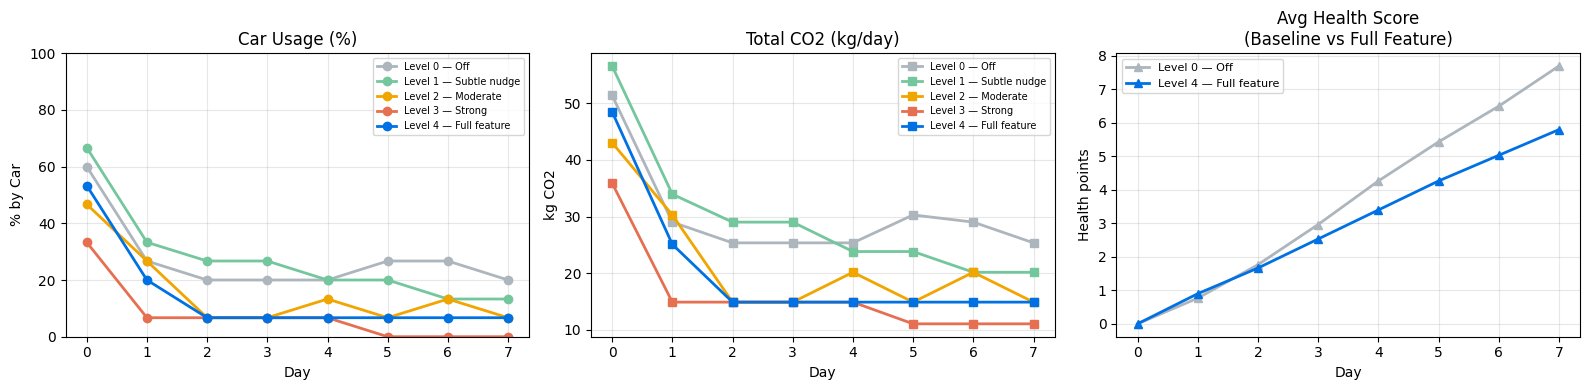

Plots saved.


In [6]:
# Reload all results from file
all_results = {}
for strength in SWEEP_VALUES:
    fname = REPORTS_DIR / f'sim_strength_{strength:.2f}.json'
    with open(fname) as f:
        all_results[str(strength)] = json.load(f)

days = list(range(N_DAYS + 1))
colors = {'0.0': '#adb5bd', '0.25': '#74c69d', '0.5': '#f0a500', '0.75': '#e76f51', '1.0': '#0071e3'}
labels = {
    '0.0':  'Level 0 — Off',
    '0.25': 'Level 1 — Subtle nudge',
    '0.5':  'Level 2 — Moderate',
    '0.75': 'Level 3 — Strong',
    '1.0':  'Level 4 — Full feature',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Car %
ax = axes[0]
for s, res in all_results.items():
    ax.plot(days, res['population']['car_pct_over_time'],
            marker='o', color=colors[s], label=labels[s], lw=2)
ax.set(title='Car Usage (%)', xlabel='Day', ylabel='% by Car')
ax.set_ylim(0, 100)
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Panel 2: CO2
ax = axes[1]
for s, res in all_results.items():
    ax.plot(days, res['population']['co2_over_time'],
            marker='s', color=colors[s], label=labels[s], lw=2)
ax.set(title='Total CO2 (kg/day)', xlabel='Day', ylabel='kg CO2')
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# Panel 3: Avg cumulative health (full feature vs baseline)
ax = axes[2]
for s in ['0.0', '1.0']:
    res = all_results[s]
    avg_health = [
        np.mean([res['agents'][a['name']]['health_history'][d] for a in AGENT_PROFILES])
        for d in range(N_DAYS + 1)
    ]
    ax.plot(days, avg_health, marker='^', color=colors[s], label=labels[s], lw=2)
ax.set(title='Avg Health Score\n(Baseline vs Full Feature)', xlabel='Day', ylabel='Health points')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'simulation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved.')

## 6 · Per-Personality Adoption & Mood Analysis (Full Feature)

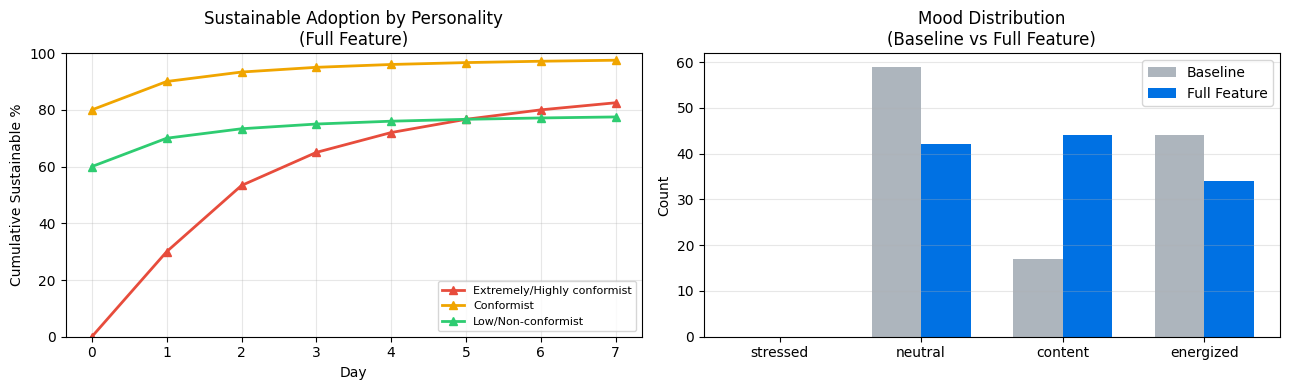

Saved.


In [7]:
full = all_results['1.0']
groups = {'Extremely/Highly conformist': [], 'Conformist': [], 'Low/Non-conformist': []}

for p in AGENT_PROFILES:
    name = p['name']
    hist = full['agents'][name]['history']
    sus_pct = [
        100 * sum(c in SUSTAINABLE_MODES for c in hist[:d+1]) / (d+1)
        for d in range(len(hist))
    ]
    t = p['conformity']
    if 'extremely' in t or 'highly' in t:
        groups['Extremely/Highly conformist'].append(sus_pct)
    elif 'non-conformist' in t or 'low' in t:
        groups['Low/Non-conformist'].append(sus_pct)
    else:
        groups['Conformist'].append(sus_pct)

# Mood distribution comparison
mood_counts = {'0.0': {m: 0 for m in ALL_MOODS}, '1.0': {m: 0 for m in ALL_MOODS}}
for s in ['0.0', '1.0']:
    for p in AGENT_PROFILES:
        for m in all_results[s]['agents'][p['name']]['mood_history']:
            if m in mood_counts[s]:
                mood_counts[s][m] += 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
group_colors = {
    'Extremely/Highly conformist': '#e74c3c',
    'Conformist': '#f0a500',
    'Low/Non-conformist': '#2ecc71',
}

ax = axes[0]
for group, series in groups.items():
    if series:
        mean = np.mean(series, axis=0)
        ax.plot(days, mean, marker='^', color=group_colors[group], label=group, lw=2)
ax.set(title='Sustainable Adoption by Personality\n(Full Feature)', xlabel='Day',
       ylabel='Cumulative Sustainable %')
ax.set_ylim(0, 100)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
x = np.arange(len(ALL_MOODS))
w = 0.35
ax.bar(x - w/2, [mood_counts['0.0'][m] for m in ALL_MOODS], w,
       label='Baseline', color='#adb5bd')
ax.bar(x + w/2, [mood_counts['1.0'][m] for m in ALL_MOODS], w,
       label='Full Feature', color='#0071e3')
ax.set_xticks(x)
ax.set_xticklabels(ALL_MOODS)
ax.set(title='Mood Distribution\n(Baseline vs Full Feature)', ylabel='Count')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'simulation_personality_mood.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 7 · Summary Table

In [8]:
import pandas as pd

rows = []
for s in SWEEP_VALUES:
    res = all_results[str(s)]
    pop = res['population']
    car_start = pop['car_pct_over_time'][0]
    car_end   = pop['car_pct_over_time'][-1]
    co2_start = pop['co2_over_time'][0]
    co2_end   = pop['co2_over_time'][-1]
    avg_health_end = np.mean([
        res['agents'][p['name']]['health_history'][-1]
        for p in AGENT_PROFILES
    ])
    energized_count = sum(
        1 for p in AGENT_PROFILES
        for m in res['agents'][p['name']]['mood_history']
        if m == 'energized'
    )
    rows.append({
        'Strength': s,
        'Feature Level': labels[str(s)],
        'Car% Day 0': f'{car_start:.1f}%',
        'Car% Day 7': f'{car_end:.1f}%',
        'Car% Delta': f'{car_end - car_start:+.1f}%',
        'CO2 Delta (kg)': f'{co2_end - co2_start:+.2f}',
        'Avg Health (end)': f'{avg_health_end:.1f}',
        '"Energized" moods': energized_count,
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

 Strength          Feature Level Car% Day 0 Car% Day 7 Car% Delta CO2 Delta (kg) Avg Health (end)  "Energized" moods
     0.00          Level 0 — Off      60.0%      20.0%     -40.0%         -26.02              7.7                 44
     0.25 Level 1 — Subtle nudge      66.7%      13.3%     -53.4%         -36.40              9.1                 52
     0.50     Level 2 — Moderate      46.7%       6.7%     -40.0%         -28.14              6.5                 34
     0.75       Level 3 — Strong      33.3%       0.0%     -33.3%         -24.83              6.1                 32
     1.00 Level 4 — Full feature      53.3%       6.7%     -46.6%         -33.59              5.8                 34
